# Creating NetCDF Files from NEXRAD Radar Rainfall from A to Z

This document walks through the process of generating NETCDF files from NEXRAD radar products. NETCDF files are useful for analysis in software like Python or R. 

The document contains code to perform the processes where necessary and explains how to do external steps. 

Sample files are contained in the root directory to perform calculations from. As some steps require outside tools, the post processed files from these steps have already been included. 

## Step 0: Set Working Directory and Import Libraries

In [1]:
import tarfile
import subprocess
from pathlib import Path
from tqdm import tqdm
import os
import time
import glob
import xarray as xr
from collections import defaultdict
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd                

try:
    # Try to find the root of the Git repository
    repo_root = Path(
        subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"],
            stderr=subprocess.DEVNULL,
            text=True
        ).strip()
    )

    # Set working directory to the Git repository root
    os.chdir(repo_root)

    print(f"Git repository detected.")
    print(f"Working directory set to:\n{repo_root}")

except (subprocess.CalledProcessError, FileNotFoundError):
    # Git repository not detected
    print("Git repository not detected.")
    
    path_input = input(
        "Enter the path to the folder containing your project: "
    ).strip()

    project_path = Path(path_input).expanduser().resolve()

    if not project_path.is_dir():
        raise FileNotFoundError(
            f"The specified directory does not exist:\n{project_path}"
        )

    os.chdir(project_path)

    print(f"Working directory set to:\n{project_path}")

Git repository detected.
Working directory set to:
/Volumes/Liams_SSD/Skan_Lake_Code/Overview_Report_Git


## Step 1: Source Radar Data

At the time of writing, (September 2026) NOAA Climate Data Online (CDO) no longer works for retrieving NEXRAD Radar data. Instead, data must be directly accessed from the Google Cloud server hosted by NOAA. The server can be found [here.](https://console.cloud.google.com/storage/browser/gcp-public-data-nexrad-l3)

To access the data, using the Google Cloud CLI (command line interface) is recommended.

The dataset is structured by year -> month -> day -> site

To select a specific site and all the days for a year the wildcard character ```*``` can be used. All togeather, this creates the command:

* ```gcloud storage cp 'gs://gcp-public-data-nexrad-l3/YYYY/MM/DD/StationID/*'```

    Where the ```*``` at the end is to select whatever file is for that day.



For example, to retrieve all the data at the Binghamton radar station in 2017 two wildcards are used like below.
* ```gcloud storage cp 'gs://gcp-public-data-nexrad-l3/2017/*/*/KBGM/*'```




After running this command, all the compressed daily files will end up in the source folder. 

For this example, run ```gcloud storage cp 'gs://gcp-public-data-nexrad-l3/2023/06/12/KBGM/*'``` in the [Sample_Day/Compressed_data](./Sample_Day/Compressed_data/) file path or run the cell below. 

In [ ]:
# after downloading gcloud, you can also run this cell to download the sample day data
# NOTE: this is a 720mib download

!gcloud storage cp 'gs://gcp-public-data-nexrad-l3/2023/06/12/KBGM/*' ./Sample_Day/Compressed_data/

## Step 2: Extract Data from Archived Files

The downloaded archived files are compressed to save space. Each day contains around 25,000 individual files, so extracting the entire day is not feasible. Instead, we can use code to extract only the datatype we are interested in. In this case we want to look at the instantaneous precipitation. From the [Federal Meteorological Handbook Part C WSR-88D](https://www.icams-portal.gov/resources/ofcm/fmh/FMH11/fmh11partC.pdf) we can find that instantaneous precipitation has the code DPR. If we open one day we can find the prefix of files we are interested in is ```KBGM_SDUS81_DPRBGM```. Now we can create code to only extract files that match our prefix. 

Below is the code required to extract only the files of interest. 


Note: The file format changed on 2013-08-12 to .tar.gz from .tar.Z. As such there is separate code not shown to navigate the .tar.Z compression format. 

In [ ]:
# Note this code may only work on MacOS or Linux, as it uses the 'tar' command-line utility. 
# If you're using Windows, you may need to install a compatible version of 'tar' or use a different method for extracting .tar.gz files.

# Define the years to process
years = [2023]  # in this case, we are only processing the year 2023

# Prefix to match
prefix = "KBGM_SDUS81_DPRBGM"

# Loop through each year
for year in years:
    print(f"\nProcessing year: {year}")
    
    # Set paths for current year
    source_folder = Path(f"./Sample_Day/Compressed_data") # these can be updated to change based on year
    destination_folder = Path(f"./Sample_Day/Uncompressed_data")
    destination_folder.mkdir(parents=True, exist_ok=True)
    
    # Check if source folder exists
    if not source_folder.exists():
        print(f"Warning: Source folder for {year} does not exist: {source_folder}")
        continue
    
    # Filter valid .tar.gz files (skip Apple resource forks)
    tar_files = [f for f in source_folder.glob("*.tar.gz") if not f.name.startswith("._")]
    
    if not tar_files:
        print(f"No .tar.gz files found for year {year}")
        continue
    
    print(f"Found {len(tar_files)} .tar.gz files for year {year}")
    
    # Loop through all .tar.gz files with progress bar
    for tar_path in tqdm(tar_files, desc=f"Extracting {year} target files"):
        try:
            with tarfile.open(tar_path, mode="r:gz") as tar:
                for member in tar.getmembers():
                    if os.path.basename(member.name).startswith(prefix):
                        tar.extract(member, path=destination_folder, filter="data")
        except Exception as e:
            print(f"\nFailed to process {tar_path.name}: {e}")

print("\nExtraction complete for all years!")

Now that we have extracted the precipitation data, we can analyses the files to see how it's structured. 

The first file is named ```KBGM_SDUS81_DPRBGM_202306120001```and the last file is ```KBGM_SDUS81_DPRBGM_202306122356```. From this we can see the file names contains the station ID, Format Standard, Type of data, station location, and a timestamp formatted as Year Month Day Hour Minute. There is no file extension and we will need a separate application to process the files into a more friendly format for analysis.

<!-- Using the Federal Meteorological Handbooks we can find out the timestamp is in UTC time code.  -->


## Step 3: Convert to NetCDF Files

To look at the data and convert it to a easier to analyze format, the [Weather Climate Toolkit](https://www.ncei.noaa.gov/products/weather-climate-toolkit) (WCT) is used. Due to the large number of files we need to process, we will use the WCT Batch Processing tool to turn each file into a NETCDF file. We also want to combine all the files for one day into a single NETCDF file with layers. This is helpful for organizational purposes. 

To preserve the longevity of our computer storage, it's best practice to perform intermediary steps on RAM. Therefore, We can save our single NETCDF layers from the WCT Batch Process to RAM and then combine all the layers for one day together and save it to our permanent location. This process reduces the number of reads and writes performed on an SSD or HDD, making them last longer. 

### Formating the Batch Processor

After downloading the WCT, the batch processor  tool can be used. The batch processor is ran with an input directory, output directory, export file type, and path to a configuration file. This results in the command: 

```call "C:\path_to_wct\wct-export.bat" "input_dir" "output_dir" File_type "config_file"```

The file type used is nc and the config file is a .xml file provided in the WCT toolkit and is modified to select how the raw radar data is converted into the specified output. For our purposes, the main lines to change are the latitude and longitude bounding box coordinates and the size of the column in the output. The row size is automatically calculated to create a grid.

Below are the lines of the config file that were changed:

```
<!-Geographic Extent Filter units of decimal degrees -->
    <minLat>42.675494934638245</minLat>
    <maxLat>42.96846134802947</maxLat>
    <minLon>-76.19171992976324</minLon>
    <maxLon>-76.49505067561005</maxLon>
```
```
<exportGridOptions>
      <!-- size of the 'long' side of the raster grid -->
      <squareGridSize>135</squareGridSize>

```


### Combine NETCDF layers into a single NETCDF file for each day

To combine all the layers in one day (usually between 200 and 400) the code below is used. Both the batch processor and the code below should be ran at the same time. The batch processor will write to the ram disk folder while the python code will read from that folder. The code will identify once all the layers for a day have been added then it will combine them into a single day netcdf. The individual layers are then deleted. This process continues until the user interrupts the code. 

Note that the code was created with the expectation that there would be a ram disk set up (possibly with a tool line [OSFMount](https://www.osforensics.com/tools/mount-disk-images.html)). Still, the code will run if this parameter is set to a normal data storage source. 

Note: This code was designed to run on Windows as the batch processor is easiest to use on that platform. 

Given the need for external tools and possibly a different operating system, the processed netcdf for the example day is already included. 

In [ ]:
# === Parameters ===
RAMDISK_FOLDER = "R:/WTC_OUTPUTS"               # RAM disk
OUTPUT_FOLDER = "./Sample_Day/Final_NetCDF"  # SSD output
NO_NEW_FILE_TIMEOUT = timedelta(seconds=20)
CHECK_INTERVAL = 10  # seconds

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# === Logging ===
LOG_FILE = os.path.join(OUTPUT_FOLDER, "processing_log.txt")

def log(message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_entry = f"[{timestamp}] {message}"
    print(log_entry)
    with open(LOG_FILE, "a") as f:
        f.write(log_entry + "\n")

# === Internal State ===
file_tracker = defaultdict(list)          # date_str -> list of files
last_seen_time = dict()                   # date_str -> last time file was added
processed_days = set()                    # date_str that were processed

def get_date_from_filename(filename):
    try:
        datecode = filename.split("_")[3].replace(".nc", "")
        return datecode[:8]  # YYYYMMDD
    except IndexError:
        return None

def process_day(date_str, files):
    log(f"Starting combine for {date_str} with {len(files)} files")
    try:
        combined = xr.open_mfdataset(sorted(files), concat_dim="time", combine="nested")
        output_file = os.path.join(OUTPUT_FOLDER, f"KBGM_DPR_{date_str}_daily.nc")
        combined.to_netcdf(output_file)
        log(f"Saved combined file: {output_file}")

        combined.close()  # <-- Add this line

        for f in files:
            os.remove(f)
        log(f"Deleted {len(files)} source files from RAM disk")
        processed_days.add(date_str)
    except Exception as e:
        log(f"ERROR combining files for {date_str}: {e}")

def watch_folder():
    log(f"Monitoring {RAMDISK_FOLDER} for NetCDF files...")
    while True:
        try:
            nc_files = glob.glob(os.path.join(RAMDISK_FOLDER, "*.nc"))
            log(f"Found {len(nc_files)} .nc files: {nc_files}")
            current_time = datetime.now()

            # Temporary: new file tracker for this iteration
            new_tracker = defaultdict(list)

            # Group files by date
            for f in nc_files:
                date = get_date_from_filename(os.path.basename(f))
                if not date:
                    continue
                new_tracker[date].append(f)

                # If file is new, update last seen
                if f not in file_tracker[date]:
                    file_tracker[date].append(f)
                    last_seen_time[date] = current_time
                    log(f"Added file {f} for date {date}, updated last_seen_time.")

            log(f"Current file_tracker: {dict(file_tracker)}")
            log(f"Current last_seen_time: {last_seen_time}")

            # Check each day for timeout
            for date, last_time in list(last_seen_time.items()):
                if date in processed_days:
                    continue
                if current_time - last_time >= NO_NEW_FILE_TIMEOUT:
                    files_to_process = file_tracker[date]
                    log(f"Timeout reached for {date}, processing {len(files_to_process)} files.")
                    process_day(date, files_to_process)
                    del file_tracker[date]
                    del last_seen_time[date]

        except Exception as e:
            log(f"ERROR in watch loop: {e}")

        time.sleep(CHECK_INTERVAL)

if __name__ == "__main__":
    watch_folder()

## Step 4: Analyze Data

Now  We have the radar data in a format that is easy to analyze. For a simple example, We can take all the data on each layer and add them together to get the cumulative precipitation over any time period we are interested in.  Below is code that will create a simple figure of the cumulative precipitation for the sample day. 

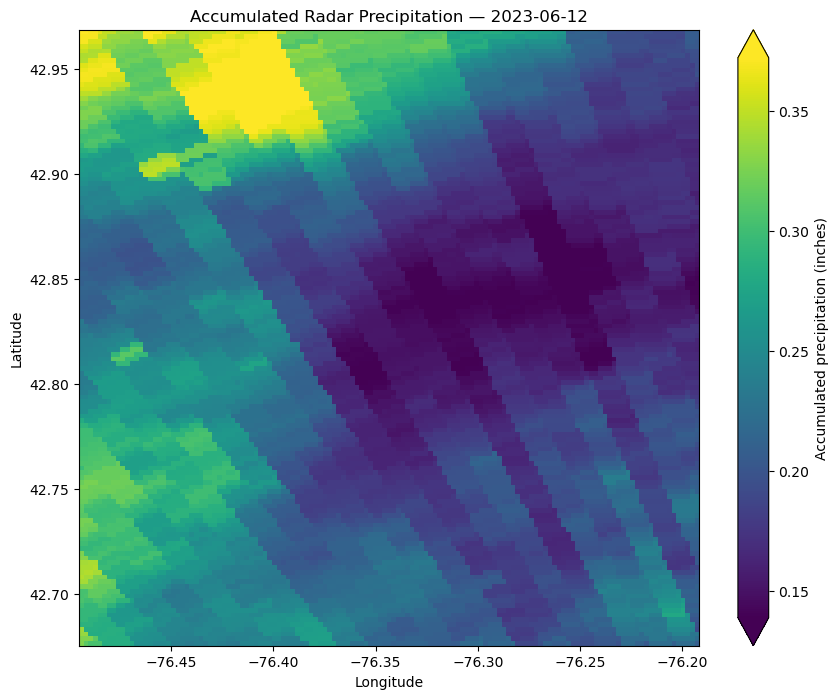

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr

# Open the daily NetCDF file
file_path = "./Sample_Day/Final_NetCDF/KBGM_DPR_20230612_daily.nc"
ds_range = xr.open_dataset(file_path)

try:
    # Precipitation variable
    data_type = "dpr"
    dpr = ds_range[data_type]

    # Calculate time differences between layers in hours
    time = ds_range["time"]
    time_diffs = (
        time[1:].values.astype("datetime64[s]")
        - time[:-1].values.astype("datetime64[s]")
    ).astype(float) / 3600.0

    # Weight each layer by the elapsed time since the previous layer
    dpr_weighted = dpr.isel(time=slice(1, None)) * xr.DataArray(
        time_diffs,
        dims=["time"],
        coords={"time": time[1:]},
    )

    # Sum weighted precipitation over time
    adjusted_data = dpr_weighted.sum(dim="time")

    # Create explicit figure and axes objects
    fig, ax = plt.subplots(figsize=(10, 8))

    adjusted_data.plot(
        ax=ax,
        cmap="viridis",
        robust=True,
        cbar_kwargs={"label": "Accumulated precipitation (inches)"},
    )

    ax.set_title("Accumulated Radar Precipitation — 2023-06-12")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")


finally:
    ds_range.close()


plt.show()

We can add shape files and landmarks to help understand what the boundaries of the data we are looking at represents. For this case we will add the outline of Skaneateles lake and its watershed to see what the precipitation into the watershed was. 

In [3]:
# Load polygon data
skan_polygon = gpd.read_file(
    "./Sample_Day/Skan_Lake/Skan_lake_polygon.shp"
)

skan_watershed = gpd.read_file(
    "./Sample_Day/Skan_Watershed/Skan_lake_watershed.shp"
)


/var/folders/w_/9_r8xct13q37vqlk_m2dxxxc0000gn/T/ipykernel_3878/921603800.py:75: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


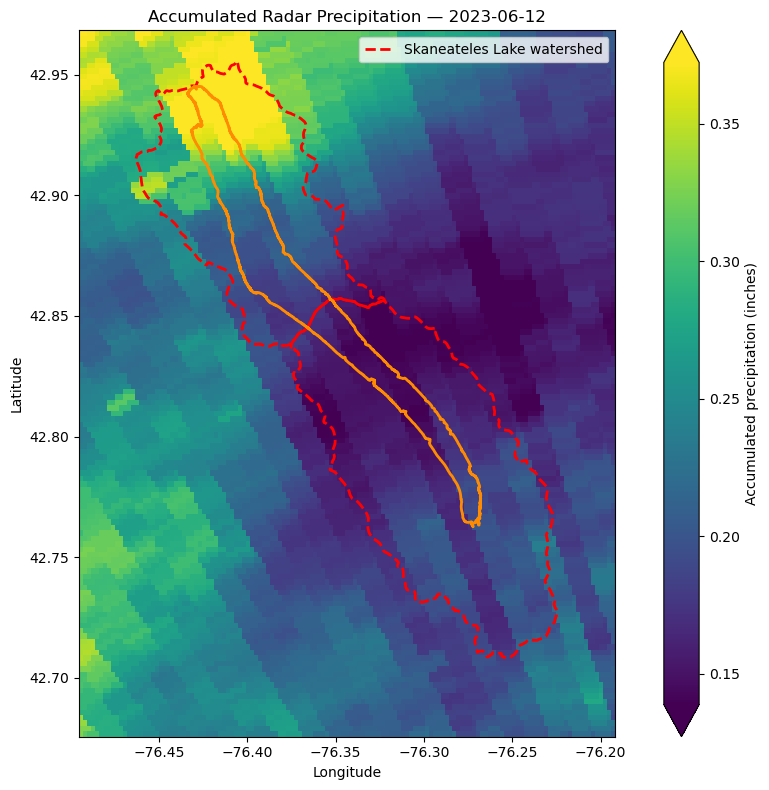

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr

# Open the daily NetCDF file
file_path = "./Sample_Day/Final_NetCDF/KBGM_DPR_20230612_daily.nc"
ds_range = xr.open_dataset(file_path)

try:
    # Precipitation variable
    data_type = "dpr"
    dpr = ds_range[data_type]

    # Calculate time differences between layers in hours
    time = ds_range["time"]
    time_diffs = (
        time[1:].values.astype("datetime64[s]")
        - time[:-1].values.astype("datetime64[s]")
    ).astype(float) / 3600.0

    # Weight each layer by elapsed time since the previous layer
    dpr_weighted = dpr.isel(time=slice(1, None)) * xr.DataArray(
        time_diffs,
        dims=["time"],
        coords={"time": time[1:]},
    )

    # Sum weighted precipitation over time
    adjusted_data = dpr_weighted.sum(dim="time")

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot accumulated precipitation
    adjusted_data.plot(
        ax=ax,
        cmap="viridis",
        robust=True,
        cbar_kwargs={"label": "Accumulated precipitation (inches)"},
    )

    # Reproject polygon layers to geographic coordinates used by the radar grid
    plot_polygon = skan_polygon
    plot_watershed = skan_watershed

    if plot_polygon.crs is not None:
        plot_polygon = plot_polygon.to_crs("EPSG:4326")

    if plot_watershed.crs is not None:
        plot_watershed = plot_watershed.to_crs("EPSG:4326")

    # Add watershed boundary
    plot_watershed.boundary.plot(
        ax=ax,
        edgecolor="red",
        linewidth=2,
        linestyle="--",
        label="Skaneateles Lake watershed",
        zorder=3,
    )

    # Add lake polygon
    plot_polygon.plot(
        ax=ax,
        facecolor="none",
        edgecolor="darkorange",
        linewidth=2,
        label="Skaneateles Lake",
        zorder=4,
    )

    ax.set_title("Accumulated Radar Precipitation — 2023-06-12")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()

    plt.tight_layout()

finally:
    ds_range.close()

plt.show()

From the plot we can see the northern village end of the lake got a lot more rain than the middle or south end of the lake. This irregularity can be hard to capture with gauge data leading to over or under predictions of how much rain fell in the watershed on any day. 

## Appendix

Code to extract wanted files from compressed archive files prior to 2013-08-12.

In [ ]:
# Define the years to process
years = [2012, 2013]  # Add or modify years as needed

# Prefix to match
prefix = "KBGM_SDUS81_DPRBGM"

# Loop through each year
for year in years:
    print(f"\nProcessing year: {year}")
    
    # Set paths for current year
    source_folder = Path(f"/Volumes/Liams_SSD/Skan_lake_data/raw_compressed_data/{year}")
    destination_folder = Path(f"/Volumes/Liams_SSD/Skan_lake_data/raw_uncompressed_data/{year}/instant_precip_Z")
    destination_folder.mkdir(parents=True, exist_ok=True)
    
    # Check if source folder exists
    if not source_folder.exists():
        print(f"Warning: Source folder for {year} does not exist: {source_folder}")
        continue
    
    # Filter valid .tar.Z files (skip Apple resource forks)
    tar_files = [f for f in source_folder.glob("*.tar.Z") if not f.name.startswith("._")]
    
    if not tar_files:
        print(f"No .tar.Z files found for year {year}")
        continue
    
    print(f"Found {len(tar_files)} .tar.Z files for year {year}")
    
    # Loop through all .tar.Z files with progress bar
    for tar_path in tqdm(tar_files, desc=f"Extracting {year} target files"):
        try:
            # Create temporary uncompressed tar file path
            temp_tar_path = tar_path.with_suffix('')  # Remove .Z extension
            
            # Decompress .Z file to .tar using system uncompress command
            result = subprocess.run(['uncompress', '-c', str(tar_path)], 
                                  stdout=open(temp_tar_path, 'wb'), 
                                  stderr=subprocess.PIPE)
            
            if result.returncode != 0:
                print(f"\nFailed to decompress {tar_path.name}")
                continue
            
            # Now process the decompressed tar file
            with tarfile.open(temp_tar_path, mode="r:") as tar:
                for member in tar.getmembers():
                    if os.path.basename(member.name).startswith(prefix):
                        tar.extract(member, path=destination_folder, filter="data")
            
            # Clean up temporary tar file
            temp_tar_path.unlink()
            
        except Exception as e:
            print(f"\nFailed to process {tar_path.name}: {e}")
            # Clean up temp file if it exists
            if 'temp_tar_path' in locals() and temp_tar_path.exists():
                temp_tar_path.unlink()

print("\nExtraction complete for all years!")